# Cereal Nutritional Visualization and Analysis
This project explores the nutritional content of 77 breakfast cereals using data source provided. The goal is to uncover insights that can guide consumers, dietitians, and product analysts in understanding how cereals differ by health characteristics, manufacturer, and shelf placement.

The notebook serves three core purposes:

1. Clustering Analysis

We apply PCA (Principal Component Analysis) and KMeans clustering to group cereals based on their nutritional profiles. This reveals patterns such as high-fiber/low-sugar clusters and visually explains them using PCA scatter plots and cluster profiling.

2. Manufacturer Comparison

By aggregating and summarizing nutritional data per manufacturer, we compare brands to identify trends and outliers in nutrient content. We also explore inter-nutrient relationships via correlation analysis.

3. Shelf-Level Comparison

Cereals are grouped by store shelf placement (levels 1–3), and average nutrient values per shelf are calculated. This helps investigate whether shelf positioning correlates with health-focused product offerings.

The outputs of this notebook—cleaned datasets, cluster labels, summary tables, and visualizations which are used to power an interactive browser-based dashboard built using D3.js.


## Section 1: Clustering Cereals Based on Nutritional Profiles


In [1]:
# Step 1: Import required libraries for preprocessing, clustering, and visualization
# We use pandas for data handling, scikit-learn for PCA and KMeans, and matplotlib for plotting.

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt


# Step 2: Load the dataset and preview the structure
# We'll first load the cereal data and inspect the columns to ensure everything looks as expected.
df = pd.read_csv("a1-cereals.csv")
df.info()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Cereal         77 non-null     object 
 1   Manufacturer   77 non-null     object 
 2   Type           77 non-null     object 
 3   Calories       77 non-null     int64  
 4   Protein        77 non-null     int64  
 5   Fat            77 non-null     int64  
 6   Sodium         77 non-null     int64  
 7   Fiber          77 non-null     float64
 8   Carbohydrates  77 non-null     float64
 9   Sugars         77 non-null     int64  
 10  Shelf          77 non-null     int64  
 11  Potassium      77 non-null     int64  
 12  Vitamins       77 non-null     int64  
 13  Weight         77 non-null     float64
 14  Cups           77 non-null     float64
dtypes: float64(4), int64(8), object(3)
memory usage: 9.2+ KB


,Cereal,Manufacturer,Type,Calories,Protein,Fat,Sodium,Fiber,Carbohydrates,Sugars,Shelf,Potassium,Vitamins,Weight,Cups
0,Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,1,70,25,1.00,0.75
1,Basic 4,G,C,130,3,2,210,2.0,18.0,8,3,100,25,1.33,0.75
2,Cheerios,G,C,110,6,2,290,2.0,17.0,1,1,105,25,1.00,1.25
3,Cinnamon Toast Crunch,G,C,120,1,3,210,0.0,13.0,9,2,45,25,1.00,0.75
4,Clusters,G,C,110,3,2,140,2.0,13.0,7,3,105,25,1.00,0.50


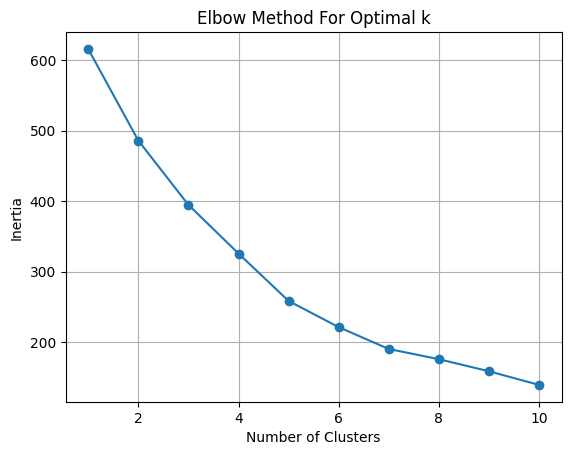

In [2]:

# Step 3: Select relevant nutritional features for clustering
# We're focusing on 8 key nutrients to understand how cereals differ based on health metrics.
features = ["Calories", "Protein", "Fat", "Sodium", "Fiber", "Carbohydrates", "Sugars", "Potassium"]
X = df[features]

# Step 4: Standardize the features
# Since nutrients are on different scales (e.g., sodium vs. protein), we standardize them for clustering and PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Determine optimal number of clusters using the Elbow Method
# We'll iterate over different 'k' values in KMeans and track inertia to find the 'elbow point' indicating optimal clustering.
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [3]:
# Step 6: Apply PCA for dimensionality reduction and run KMeans clustering
# PCA reduces dimensions to 2 for visualization while preserving variance. KMeans groups the cereals into 3 clusters.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 7: Store cluster labels and PCA coordinates in the original DataFrame
# This step enriches the original dataset with cluster and PCA information for further analysis and visualization.

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]
df["Cluster"] = clusters

# Step 8: Save the enhanced dataset to CSV for later use in D3.js or reporting
df.to_csv("final_cereal_analysis.csv", index=False)
df.head()

,Cereal,Manufacturer,Type,Calories,Protein,Fat,Sodium,Fiber,Carbohydrates,Sugars,Shelf,Potassium,Vitamins,Weight,Cups,PCA1,PCA2,Cluster
0,Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,1,70,25,1.00,0.75,-0.299099,1.174957,1
1,Basic 4,G,C,130,3,2,210,2.0,18.0,8,3,100,25,1.33,0.75,-0.377583,1.285368,1
2,Cheerios,G,C,110,6,2,290,2.0,17.0,1,1,105,25,1.00,1.25,1.154164,0.121731,2
3,Cinnamon Toast Crunch,G,C,120,1,3,210,0.0,13.0,9,2,45,25,1.00,0.75,-1.467874,1.739100,1
4,Clusters,G,C,110,3,2,140,2.0,13.0,7,3,105,25,1.00,0.50,0.443267,0.710073,1


In [4]:

# Step 9: Calculate average nutrient profile for each cluster
# This gives insight into what defines each cluster — for example, high fiber or high sugar groups.
cluster_profiles = df.groupby('Cluster')[features].mean().round(2)

cluster_profiles

,Calories,Protein,Fat,Sodium,Fiber,Carbohydrates,Sugars,Potassium
Cluster,,,,,,,,
0,72.50,4.25,1.00,132.50,8.93,4.75,2.50,260.00
1,118.00,2.28,1.50,164.12,1.78,13.22,10.50,94.85
2,97.58,2.67,0.42,157.58,1.79,17.45,3.12,77.70


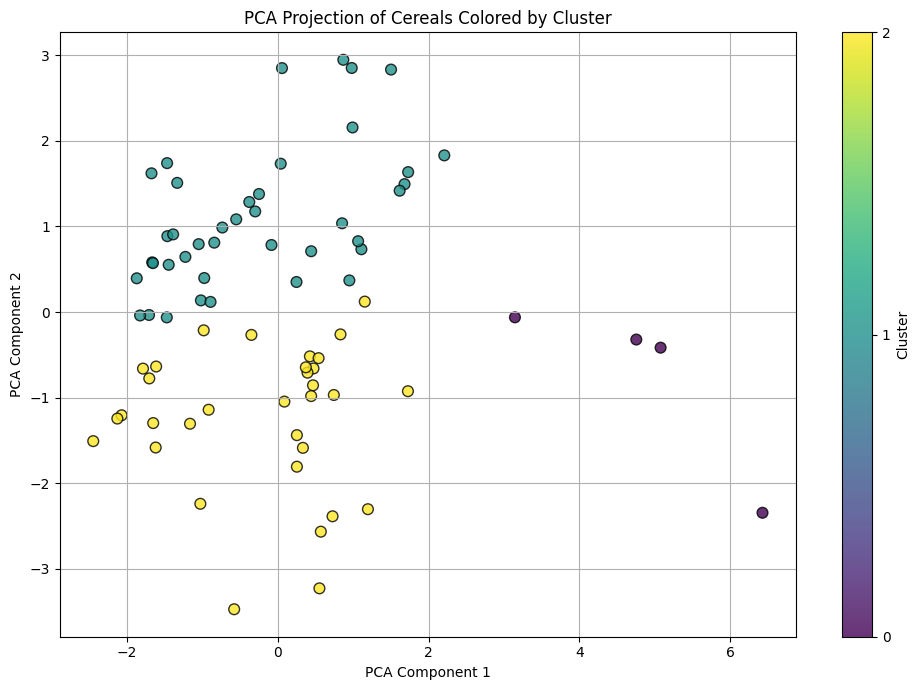

In [5]:
# Step 10: Visualize the PCA projection with color-coded clusters
# We use matplotlib and seaborn to visualize how well the clusters are separated in 2D space.
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis', s=60, alpha=0.8, edgecolor='k')
plt.title("PCA Projection of Cereals Colored by Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Cluster')
plt.tight_layout()
plt.show()


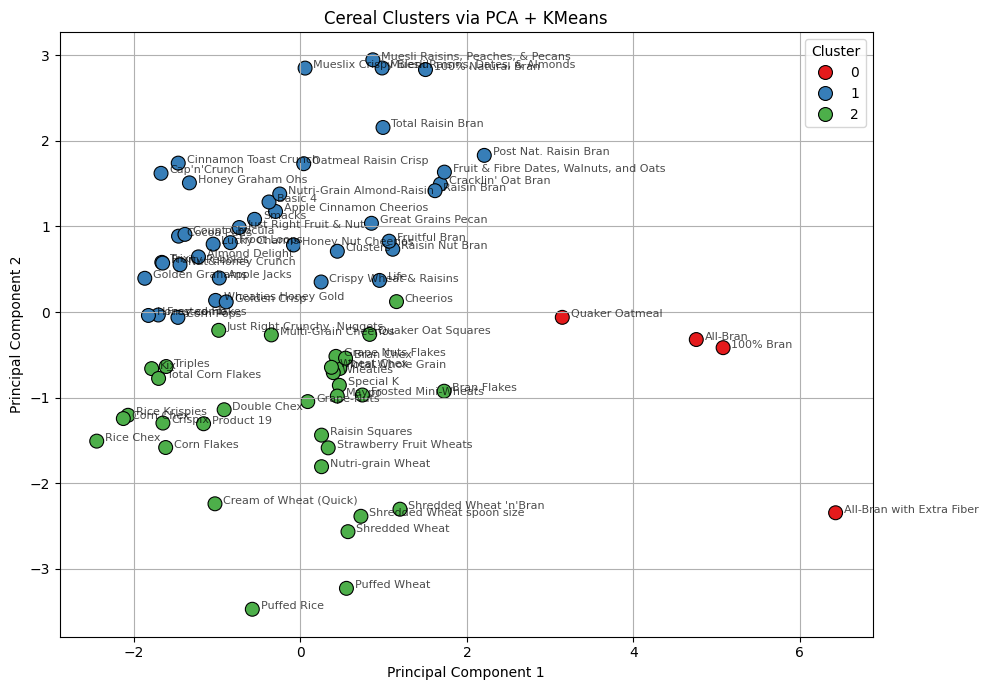

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 11: Annotate the PCA scatter plot with cereal names
# This adds interpretability to the plot — useful for labeling and understanding cluster compositions.

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100,
    edgecolor='black'
)

# Annotate points with cereal names
for i in range(df.shape[0]):
    plt.text(df.PCA1[i]+0.1, df.PCA2[i], df.Cereal[i], fontsize=8, alpha=0.7)

plt.title('Cereal Clusters via PCA + KMeans')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


## Section 2: Nutritional Analysis by Manufacturer


Data loaded: 77 rows, 15 columns

Available columns:
['Cereal', 'Manufacturer', 'Type', 'Calories', 'Protein', 'Fat', 'Sodium', 'Fiber', 'Carbohydrates', 'Sugars', 'Shelf', 'Potassium', 'Vitamins', 'Weight', 'Cups']

Missing values:
 Sugars           0
Fiber            0
Sodium           0
Protein          0
Potassium        0
Calories         0
Carbohydrates    0
Fat              0
dtype: int64

Manufacturer summary created:

Saved to 'data/cereal_manufacturer_summary.csv'


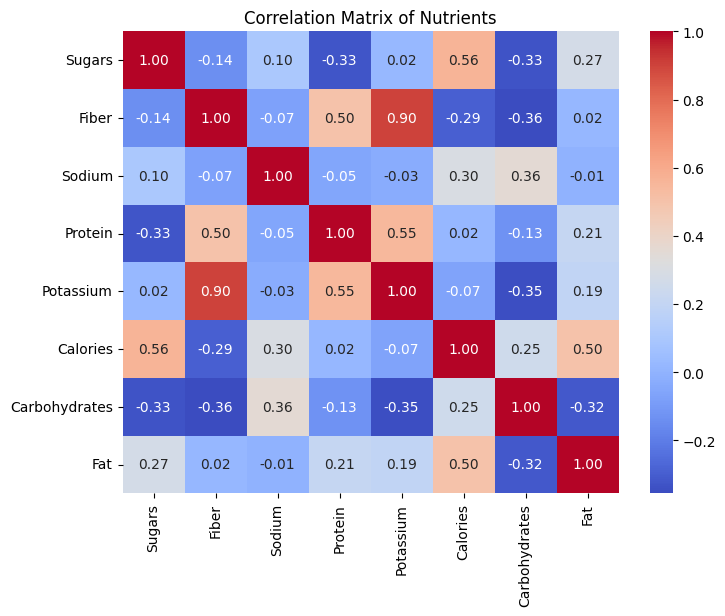


Saved 'nutrient_correlation_matrix.csv' as well


In [7]:
# Cereal Manufacturer Nutritional Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset and inspect structure
# This analysis aims to compare nutritional trends across different cereal manufacturers.
df = pd.read_csv('a1-cereals.csv')
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

# Step 2: Identify key nutrient columns and check for missing values
# Ensures data integrity before aggregating by manufacturer.
print("\nAvailable columns:")
print(df.columns.tolist())

# Basic Data Cleaning
# Some columns may have missing values — we'll fill them with median values if needed.
nutrients = ['Sugars', 'Fiber', 'Sodium', 'Protein', 'Potassium', 'Calories', 'Carbohydrates', 'Fat']

# Check missing
missing_counts = df[nutrients].isnull().sum()
print("\nMissing values:\n", missing_counts)

# Step 3: Impute missing values using median substitution
# We apply median imputation to handle any missing values conservatively, preventing bias.
df[nutrients] = df[nutrients].fillna(df[nutrients].median())

# Step 4: Group data by manufacturer and compute mean, median, min, max for each nutrient
# This creates a summary view of each brand’s overall nutritional tendencies.
manufacturer_summary = df.groupby('Manufacturer')[nutrients].agg(['mean', 'median', 'min', 'max'])
manufacturer_summary.columns = ['_'.join(col).strip() for col in manufacturer_summary.columns.values]
manufacturer_summary.reset_index(inplace=True)

print("\nManufacturer summary created:")
manufacturer_summary.head()

# Step 5: Save the manufacturer summary as CSV for use in D3 visualizations or further analysis
manufacturer_summary.to_csv('cereal_manufacturer_summary.csv', index=False)
print("\nSaved to 'data/cereal_manufacturer_summary.csv'")

# Step 6: Generate and visualize correlation matrix between nutrients
# Helps discover how nutrient values are interrelated — e.g., high sugar may correlate with low fiber.
corr_matrix = df[nutrients].corr()

# Visualize
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Nutrients")
plt.show()

# Step 7: Save the correlation matrix for use in heatmaps or dashboard integration
corr_matrix.to_csv('nutrient_correlation_matrix.csv')
print("\nSaved 'nutrient_correlation_matrix.csv' as well")


## Section 3: Shelf-Level Nutritional Comparison

In [8]:
# Step 1: Load the dataset and define the nutritional features of interest
# We'll compare average nutrition values across different shelf levels in a retail setting.

import pandas as pd

# Load the cereal dataset
df = pd.read_csv('a1-cereals.csv')

# Relevant nutrients we want to average
nutrients = ['Calories', 'Protein', 'Fat', 'Sodium', 'Fiber', 'Carbohydrates', 'Sugars', 'Potassium']

# Step 2: Group cereals by Shelf and calculate mean values per nutrient
# Helps identify whether shelf placement corresponds with healthier or unhealthier cereal offerings.
shelf_summary = df.groupby('Shelf')[nutrients].mean().reset_index()

# Step 3: Round the values for presentation clarity and export to CSV for visualization use
shelf_summary = shelf_summary.round(2)

shelf_summary.to_csv('shelf_nutrition_summary.csv', index=False)


shelf_summary.head()



,Shelf,Calories,Protein,Fat,Sodium,Fiber,Carbohydrates,Sugars,Potassium
0,1,102.50,2.65,0.60,176.25,1.68,15.80,4.80,75.50
1,2,109.52,1.90,1.00,145.71,0.90,13.62,9.62,57.81
2,3,107.78,2.86,1.25,158.61,3.14,14.50,6.53,129.83
